### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [1]:
import pandas as pd 
import numpy as np
from scipy.sparse import dia_matrix, csc_matrix
from scipy.sparse.linalg import inv
import matplotlib.pyplot as plt
from datetime import datetime
import sys
from scipy.interpolate import interp1d
from scipy.stats import iqr
import ruptures as rpt
from sklearn.model_selection import train_test_split
import time




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0)


trades=trades[trades.index < "2020-01-15 15:59:30"]
trades=trades[trades.index> "2020-01-15 15:50:00"]

trades['Trade_Price']=np.log(trades['Trade_Price'])
trades

,SIP_Timestamp,Exchange,Symbol,Trade_Volume,Trade_Price,Sale_Condition,Source_of_Trade,Trade_Correction_Indicator,Sequence_Number,Trade_Id,Trade_Reporting_Facility,Trade_Through_Exempt_Indicator,date
2020-01-15 15:50:00.031456,2020-01-15 15:50:00.031835,N,AAPL,198,5.738699,@F,N,0,2724464,5343,,1,2020-01-15
2020-01-15 15:50:00.052959,2020-01-15 15:50:00.053341,N,AAPL,200,5.738860,@F,N,0,2724891,5344,,1,2020-01-15
2020-01-15 15:50:00.120924,2020-01-15 15:50:00.121313,N,AAPL,400,5.738989,@F,N,0,2725997,5345,,1,2020-01-15
2020-01-15 15:50:00.120924,2020-01-15 15:50:00.121314,N,AAPL,600,5.739021,@F,N,0,2725998,5346,,1,2020-01-15
2020-01-15 15:50:00.120924,2020-01-15 15:50:00.121314,N,AAPL,200,5.739053,@F,N,0,2725999,5347,,1,2020-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 15:59:25.573634,2020-01-15 15:59:25.574009,N,AAPL,46,5.740404,@ I,N,0,2937032,5653,,0,2020-01-15
2020-01-15 15:59:26.015345,2020-01-15 15:59:26.015721,N,AAPL,40,5.740436,@ I,N,0,2937404,5654,,0,2020-01-15
2020-01-15 15:59:29.176621,2020-01-15 15:59:29.177000,N,AAPL,97,5.740500,@ I,N,0,2939443,5655,,0,2020-01-15
2020-01-15 15:59:29.920769,2020-01-15 15:59:29.921147,N,AAPL,100,5.740661,@,N,0,2940442,5656,,0,2020-01-15


Text(0.5, 1.0, 'APPL Trade Price 01/15/2020')

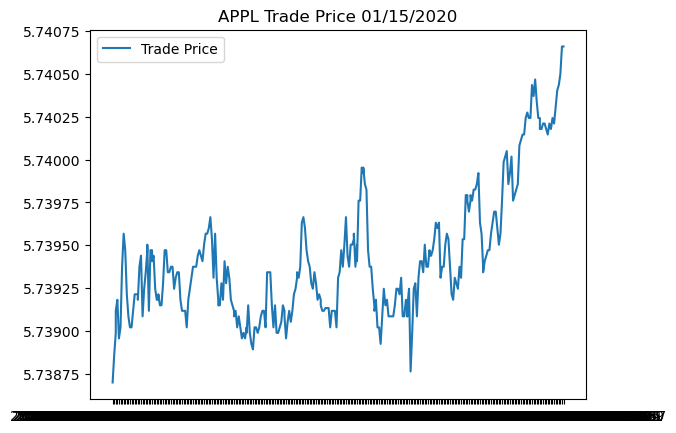

In [3]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/15/2020")

In [4]:
vol=trades['Trade_Volume']

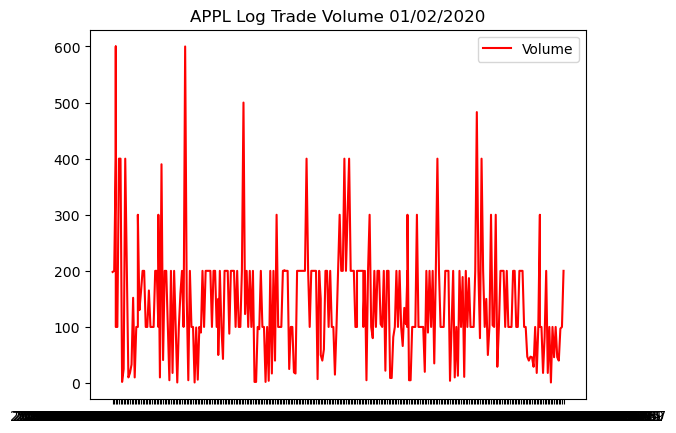

In [5]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Extension for irregularly spaced time and Adaptive Penalty

### Unit Test 1

For both unit tests we pass in an array of differences in time 

For each trend filtering problem, the filtered signal is returned with the normalized D_DT Inverse



In [6]:
t=np.arange(0,len(trades.index))
t1=np.cumsum(np.pad(np.diff(t),(1,0),'constant',constant_values=t[1]))

In [7]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt1,status,eq_D=l1tf_adaptive_ir(y,lambda_p=10)

pobj1: [[6357.49644037]], pobj2: [[0.39018484]], dobj: [[0.]], gap: [[0.39018484]]
pobj1: [[9.52715576e+12]], pobj2: [[0.04594903]], dobj: [[1.32087271e-06]], gap: [[0.04594771]]
pobj1: [[6.32253942e+09]], pobj2: [[0.00768805]], dobj: [[3.434838e-06]], gap: [[0.00768461]]
pobj1: [[3711205.41369394]], pobj2: [[0.00086691]], dobj: [[5.52314698e-06]], gap: [[0.00086138]]
pobj1: [[3623.77471095]], pobj2: [[0.00016668]], dobj: [[7.83292371e-06]], gap: [[0.00015884]]
pobj1: [[6.95660019]], pobj2: [[5.58094857e-05]], dobj: [[1.20284936e-05]], gap: [[4.3780992e-05]]
pobj1: [[59.75981682]], pobj2: [[1.86653259e-05]], dobj: [[1.29336339e-05]], gap: [[5.73169193e-06]]
pobj1: [[93.7391721]], pobj2: [[1.32756998e-05]], dobj: [[1.29527192e-05]], gap: [[3.22980591e-07]]
pobj1: [[97.31387078]], pobj2: [[1.29633039e-05]], dobj: [[1.29527792e-05]], gap: [[1.05246779e-08]]
pobj1: [[97.49059329]], pobj2: [[1.29530947e-05]], dobj: [[1.29527792e-05]], gap: [[3.15440788e-10]]
solved
pobj1: [[97.49059329]], p

In [8]:
print(np.linalg.cond(eq_D))
print(np.round(eq_D,4))
print(np.linalg.cond(eq_D))

17739.370094127084
[[ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]]
17739.370094127084


Note the equivalence in difference matrix

Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

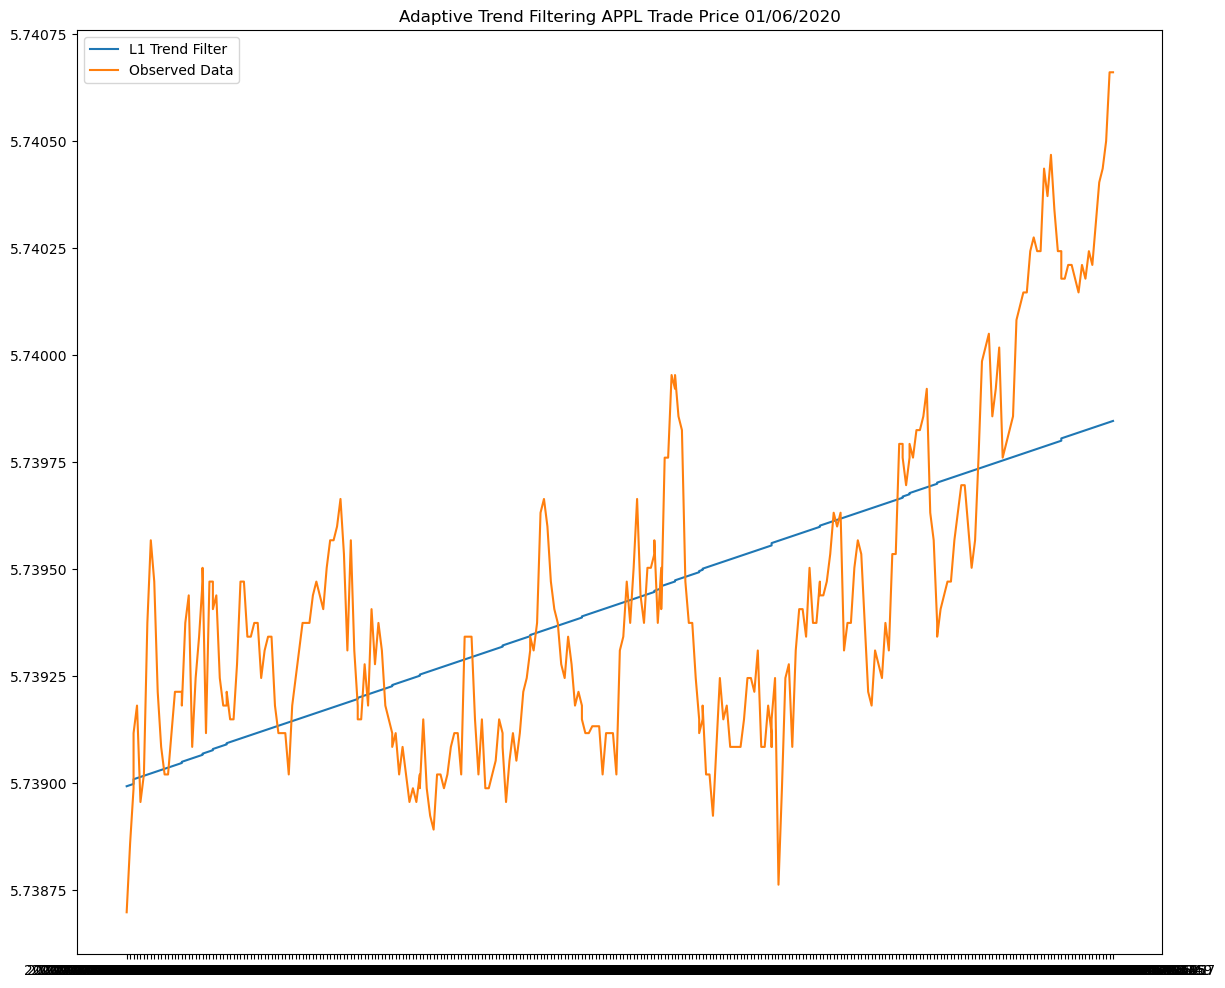

In [9]:
fig,ax=plt.subplots(figsize=(14,12))
ax.plot(trades.index,x_adapt1,label= 'L1 Trend Filter')
ax.plot(trades.index,y, label='Observed Data')


ax.legend()
ax.set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Unit Test 2

Uniformly sampled data within the range (0.999999,1.000001)

Leads me to believe the optimization is ill=conditioned 

In [10]:
a=.9
b=1.1

t2=np.cumsum(np.random.rand(len(y))*(b-a)+a)

t2

array([  0.96766533,   1.97290913,   3.014653  ,   4.03854395,
         5.01670348,   5.92118146,   6.98364017,   8.0481314 ,
         9.00614382,   9.92510122,  10.87838225,  11.97125166,
        13.06012061,  14.01128273,  15.09260128,  16.04351504,
        17.03184386,  18.13037674,  19.19700158,  20.24905771,
        21.23476537,  22.31246713,  23.26518611,  24.31853579,
        25.31825729,  26.32828733,  27.4212258 ,  28.33207751,
        29.36579909,  30.3282941 ,  31.37441248,  32.29515253,
        33.2321345 ,  34.22235586,  35.22629942,  36.25374591,
        37.23397371,  38.2162368 ,  39.13224728,  40.09617818,
        40.99818782,  41.93916585,  43.00208243,  43.9217873 ,
        45.01882892,  46.00344453,  47.03114095,  48.07763408,
        49.03668861,  50.0729655 ,  51.15321789,  52.20471019,
        53.28450817,  54.20635903,  55.12540668,  56.16239073,
        57.20917378,  58.21375975,  59.18444842,  60.20758383,
        61.24630252,  62.28322502,  63.19281108,  64.27

In [11]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt2,status,D_2=l1tf_adaptive_ir(y,t=t2,lambda_p=1.0)

pobj1: [[2596.21205111]], pobj2: [[0.1559111]], dobj: [[0.]], gap: [[0.1559111]]
pobj1: [[9.56623455e+12]], pobj2: [[0.02709246]], dobj: [[1.06212085e-06]], gap: [[0.0270914]]
pobj1: [[6.58748021e+09]], pobj2: [[0.00468883]], dobj: [[2.87764369e-06]], gap: [[0.00468595]]
pobj1: [[4838640.23851658]], pobj2: [[0.00059626]], dobj: [[5.12055279e-06]], gap: [[0.00059114]]
pobj1: [[7887.76993166]], pobj2: [[0.00011539]], dobj: [[7.01855387e-06]], gap: [[0.00010837]]
pobj1: [[108.98411363]], pobj2: [[4.14066888e-05]], dobj: [[1.01544108e-05]], gap: [[3.12522779e-05]]
pobj1: [[8.30648047]], pobj2: [[2.26221359e-05]], dobj: [[1.25166964e-05]], gap: [[1.01054395e-05]]
pobj1: [[63.8871464]], pobj2: [[1.5126238e-05]], dobj: [[1.29270127e-05]], gap: [[2.19922528e-06]]
pobj1: [[92.05971198]], pobj2: [[1.32226737e-05]], dobj: [[1.29523845e-05]], gap: [[2.70289257e-07]]
pobj1: [[96.98709098]], pobj2: [[1.29733094e-05]], dobj: [[1.29527771e-05]], gap: [[2.05322972e-08]]
pobj1: [[97.460029]], pobj2: [[1

In [12]:
print(np.round(D_2,4))

print(np.linalg.matrix_rank(D_2),D_2.shape)
print(np.linalg.cond(D_2))

[[ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]]
313 (313, 315)
17739.370094127084


### Unit Test 3

In [13]:
a=0
b=2

t3=np.cumsum(np.random.rand(len(trades.index))*(b-a)+a)


t3

array([  0.74853576,   1.9345432 ,   2.9563593 ,   3.02070776,
         4.55521538,   6.20733214,   8.03272632,   8.3989882 ,
         9.37322233,  10.03997807,  10.86156858,  12.51182212,
        13.45539345,  15.25456722,  16.45655798,  17.3501814 ,
        19.21259285,  19.70955378,  20.56131659,  21.20561067,
        21.50555161,  23.344056  ,  24.40319941,  25.66201208,
        26.70721427,  27.79431805,  28.50774607,  28.67281268,
        30.43099846,  32.02817608,  33.48146221,  35.15828535,
        35.97654497,  37.27932067,  37.43855673,  37.97587636,
        39.22553761,  40.22034298,  42.18956187,  43.13948542,
        44.06330087,  45.14588131,  46.49383611,  47.60053597,
        48.4195773 ,  48.90057358,  49.3689635 ,  49.36984008,
        50.05289133,  50.23087882,  52.01046643,  52.05108458,
        53.75900522,  53.91364102,  55.17864661,  56.53486143,
        57.09607656,  58.5206548 ,  59.87761353,  59.95710497,
        61.22069616,  61.9702396 ,  63.87369004,  64.45

In [14]:


y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt3,status,D_3=l1tf_adaptive_ir(y,t=t3,lambda_p=1)

pobj1: [[9185.85704674]], pobj2: [[0.69123072]], dobj: [[0.]], gap: [[0.69123072]]
pobj1: [[9.68087358e+12]], pobj2: [[0.03564605]], dobj: [[1.10949813e-06]], gap: [[0.03564494]]
pobj1: [[6.63508103e+09]], pobj2: [[0.00523873]], dobj: [[2.97490948e-06]], gap: [[0.00523575]]
pobj1: [[4803389.59067664]], pobj2: [[0.0006518]], dobj: [[5.2130632e-06]], gap: [[0.00064659]]
pobj1: [[7543.79975327]], pobj2: [[0.00012497]], dobj: [[7.15175384e-06]], gap: [[0.00011782]]
pobj1: [[123.1144596]], pobj2: [[4.39849529e-05]], dobj: [[1.03885619e-05]], gap: [[3.3596391e-05]]
pobj1: [[9.88307981]], pobj2: [[2.28035292e-05]], dobj: [[1.25672803e-05]], gap: [[1.02362488e-05]]
pobj1: [[68.0424881]], pobj2: [[1.49413214e-05]], dobj: [[1.29333434e-05]], gap: [[2.00797801e-06]]
pobj1: [[93.44588888]], pobj2: [[1.31612762e-05]], dobj: [[1.2952571e-05]], gap: [[2.08705218e-07]]
pobj1: [[97.18228459]], pobj2: [[1.29658473e-05]], dobj: [[1.29527785e-05]], gap: [[1.30687629e-08]]
pobj1: [[97.47779475]], pobj2: [[

In [15]:
print(np.round(D_3,4))

print(np.linalg.matrix_rank(D_3),D_3.shape)
print(np.linalg.cond(D_3))

[[ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]]
313 (313, 315)
17739.370094127084


In [16]:
a=0
b=10

t4=np.cumsum(np.random.rand(len(trades.index))*(b-a)+a)


t4

array([   8.4925582 ,   16.91441301,   18.14029443,   25.12117614,
         32.89742786,   37.08384242,   44.91997448,   47.93115424,
         48.31876647,   51.43191591,   59.22214923,   68.07090714,
         71.96149805,   78.32983554,   83.40937675,   89.10977495,
         90.12461137,   96.51468949,  105.07486181,  114.9950168 ,
        120.41392447,  120.66353387,  129.85341865,  137.39026528,
        137.70213604,  143.82284555,  147.24139404,  148.69039467,
        155.61180325,  162.59162594,  164.71129891,  168.06210091,
        177.88546423,  179.69260059,  180.2054379 ,  185.45999818,
        186.06110996,  189.49818376,  190.18747265,  190.51653377,
        197.47783625,  200.88447255,  209.01441021,  216.17323755,
        221.38593768,  229.82897981,  231.25768772,  236.6614762 ,
        237.29854039,  240.66508753,  246.41981094,  255.0292652 ,
        257.45851818,  265.92272563,  273.62082527,  275.34828405,
        284.52960412,  288.14026396,  295.76570655,  297.79365

In [17]:

y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt4,status,D_4=l1tf_adaptive_ir(y,t=t4,lambda_p=1)

pobj1: [[5105.08815824]], pobj2: [[0.28973368]], dobj: [[0.]], gap: [[0.28973368]]
pobj1: [[9.54931887e+12]], pobj2: [[0.03564895]], dobj: [[1.19100467e-06]], gap: [[0.03564776]]
pobj1: [[6.38353121e+09]], pobj2: [[0.0061644]], dobj: [[3.186919e-06]], gap: [[0.00616122]]
pobj1: [[4227994.43050948]], pobj2: [[0.00069827]], dobj: [[5.31390146e-06]], gap: [[0.00069295]]
pobj1: [[5855.30066921]], pobj2: [[0.00013512]], dobj: [[7.36232656e-06]], gap: [[0.00012776]]
pobj1: [[65.06592214]], pobj2: [[4.80070138e-05]], dobj: [[1.09746062e-05]], gap: [[3.70324076e-05]]
pobj1: [[25.3909665]], pobj2: [[2.16653635e-05]], dobj: [[1.27726733e-05]], gap: [[8.89269019e-06]]
pobj1: [[81.45042124]], pobj2: [[1.41632099e-05]], dobj: [[1.2948652e-05]], gap: [[1.21455797e-06]]
pobj1: [[96.01744353]], pobj2: [[1.30335819e-05]], dobj: [[1.29527631e-05]], gap: [[8.08187933e-08]]
pobj1: [[97.41288513]], pobj2: [[1.29565758e-05]], dobj: [[1.29527792e-05]], gap: [[3.79659331e-09]]
solved
pobj1: [[97.41288513]], p

In [18]:
print(np.round(D_4,4))

print(np.linalg.matrix_rank(D_4),D_4.shape)
print(np.linalg.cond(D_4))

[[ 1. -2.  1. ...  0.  0.  0.]
 [ 0.  1. -2. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -2.  1.  0.]
 [ 0.  0.  0. ...  1. -2.  1.]]
313 (313, 315)
17739.370094127084


Text(0.5, 0.98, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

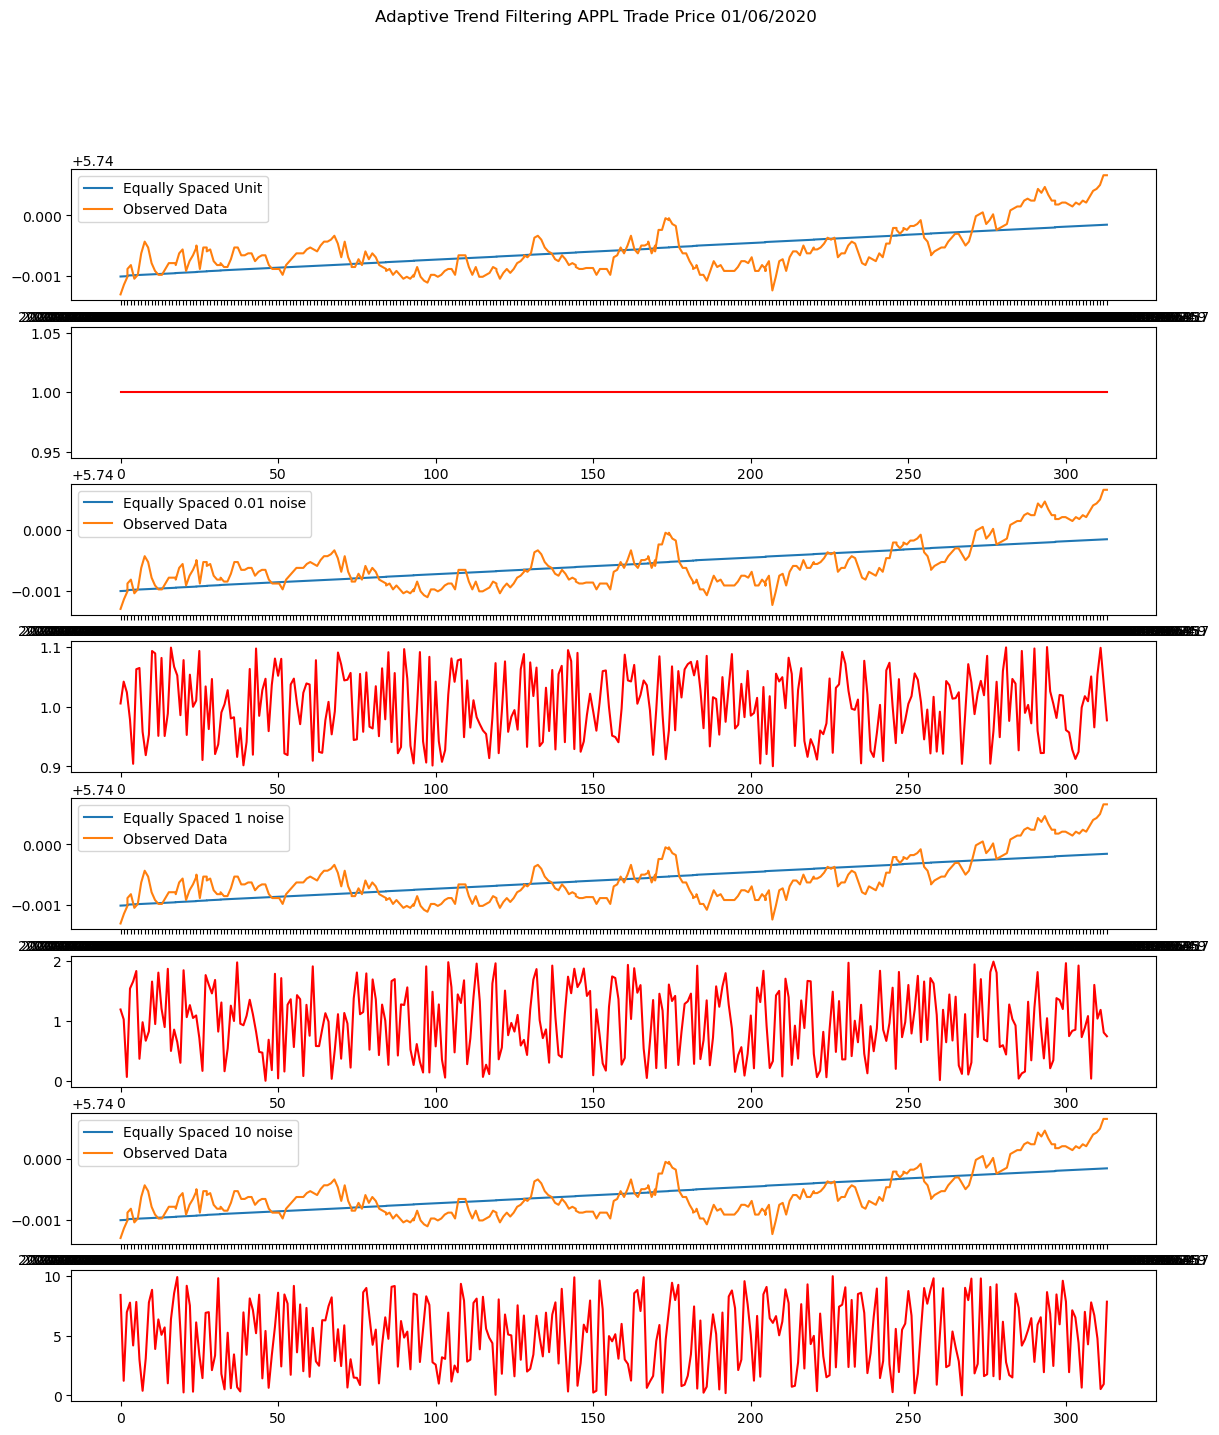

In [19]:
fig,ax=plt.subplots(8,1,figsize=(14,16))
ax[0].plot(trades.index,x_adapt1,label= 'Equally Spaced Unit')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(np.diff(t1),color='red')

ax[2].plot(trades.index,x_adapt2,label= 'Equally Spaced 0.01 noise')
ax[2].plot(trades.index,y, label='Observed Data')

ax[3].plot(np.diff(t2),color='red')

ax[4].plot(trades.index,x_adapt3,label= 'Equally Spaced 1 noise')
ax[4].plot(trades.index,y, label='Observed Data')

ax[5].plot(np.diff(t3),color='red')

ax[6].plot(trades.index,x_adapt4,label= 'Equally Spaced 10 noise')
ax[6].plot(trades.index,y, label='Observed Data')

ax[7].plot(np.diff(t4),color='red')

ax[0].legend()
ax[2].legend()
ax[4].legend()
ax[6].legend()

fig.suptitle("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

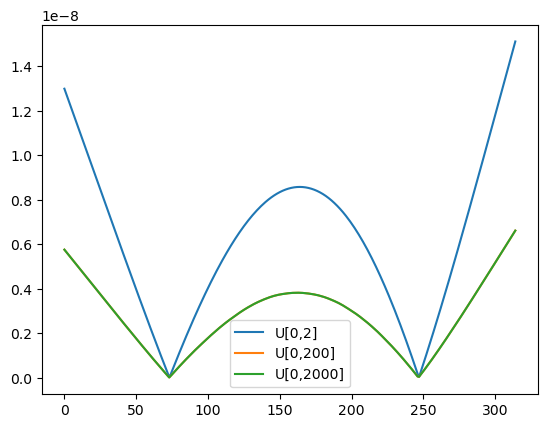

In [20]:
plt.plot(abs(x_adapt1-x_adapt2),label='U[0,2]')
plt.plot(abs(x_adapt1-x_adapt3),label='U[0,200]')
plt.plot(abs(x_adapt1-x_adapt3),label='U[0,2000]')
plt.legend()

### Unit Test factoring of irregular timesteps

Adjust our penalty by the time factor

Unit test by applying an extremely large time difference with white noise time differences all around

In [21]:
a=0.99
b=1.01

t_unit=np.concatenate([((np.random.rand(100))*(b-a)+a),((np.random.rand(2))*(b-a)+a)*2000*np.ones(2),((np.random.rand(len(y)-102))*(b-a)+a)])
t_unit

array([9.95373331e-01, 9.93354092e-01, 1.00411828e+00, 9.92412016e-01,
       1.00437701e+00, 9.97098503e-01, 1.00946202e+00, 1.00867667e+00,
       1.00066295e+00, 9.95305003e-01, 1.00113547e+00, 1.00229873e+00,
       9.90824619e-01, 9.96479872e-01, 1.00422475e+00, 9.95991666e-01,
       9.93940381e-01, 1.00397130e+00, 9.95590397e-01, 1.00003433e+00,
       1.00468454e+00, 9.95512463e-01, 9.93736280e-01, 9.99248721e-01,
       1.00598892e+00, 9.91622171e-01, 1.00133070e+00, 9.90470537e-01,
       1.00974474e+00, 1.00986962e+00, 9.90577636e-01, 9.91150729e-01,
       1.00927118e+00, 9.94850760e-01, 9.91255410e-01, 9.96428153e-01,
       9.94076782e-01, 9.94267445e-01, 1.00382497e+00, 1.00175925e+00,
       9.91569533e-01, 9.97422154e-01, 9.90563929e-01, 1.00565474e+00,
       1.00429666e+00, 9.94085079e-01, 9.90503051e-01, 9.93985777e-01,
       9.97005869e-01, 1.00807422e+00, 1.00019537e+00, 1.00070457e+00,
       9.90762286e-01, 9.90916506e-01, 9.97490323e-01, 1.00864383e+00,
      

In [22]:
y=trades['Trade_Price'].values.reshape(-1,1)

x_adapt5,status,D_5=l1tf_adaptive_ir(y,t=t_unit,lambda_p=.01)

pobj1: [[7196.80205252]], pobj2: [[0.48306181]], dobj: [[0.]], gap: [[0.48306181]]
pobj1: [[9.79739808e+12]], pobj2: [[0.0281307]], dobj: [[1.01118375e-06]], gap: [[0.02812969]]
pobj1: [[7.09327901e+09]], pobj2: [[0.00388363]], dobj: [[2.65659387e-06]], gap: [[0.00388098]]
pobj1: [[8375677.85550832]], pobj2: [[0.00049316]], dobj: [[4.85595764e-06]], gap: [[0.0004883]]
pobj1: [[48128.76133558]], pobj2: [[0.00010314]], dobj: [[6.43309237e-06]], gap: [[9.67046169e-05]]
pobj1: [[521.4661431]], pobj2: [[3.17946984e-05]], dobj: [[8.38737061e-06]], gap: [[2.34073278e-05]]
pobj1: [[62.65305217]], pobj2: [[1.61188444e-05]], dobj: [[9.926194e-06]], gap: [[6.19265045e-06]]
pobj1: [[32.2939231]], pobj2: [[1.16045083e-05]], dobj: [[1.03109589e-05]], gap: [[1.29354942e-06]]
pobj1: [[27.01241484]], pobj2: [[1.0542733e-05]], dobj: [[1.03633109e-05]], gap: [[1.79422134e-07]]
pobj1: [[26.07155233]], pobj2: [[1.03968493e-05]], dobj: [[1.03754139e-05]], gap: [[2.14354269e-08]]
pobj1: [[25.86964524]], pobj

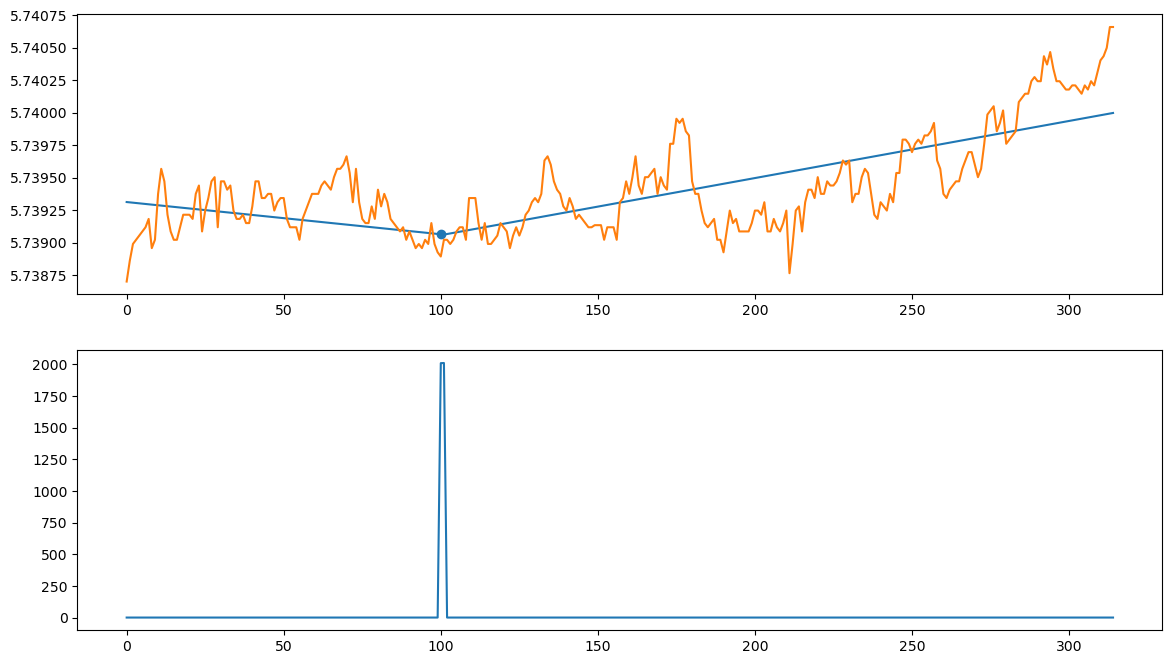

In [23]:
fig,ax=plt.subplots(2,1,figsize=(14,8))
ax[0].plot(np.arange(0,len(y)),x_adapt5,label= 'Equally Spaced Unit')
ax[0].plot(np.arange(0,len(y)),y, label='Observed Data')
ax[0].scatter(100,x_adapt5[100])
ax[1].plot (t_unit)